# Lab 8: Estimation

**Attention:**

1. **Using the Notebook**
    - Use Jupyter Notebook as instructed. We do **not** have the resources to support Anaconda or VS Code. 
    - Provide your answers in the designated spaces.
    - Do not reassign variables! For example, if you use `max_temperature` for one question, do not reassign it later on (e.g., as an intermediate variable). Doing so may cauae you to fail tests you passed previously!
2. **Grading**:
    - Points may be scaled in Canvas.
    - Most tests check the format and data types of your answers, not their correctness. Passing the tests does not guarantee the grade will be 100%.
3. Academic honor:
    - **DO NOT CHEAT!** Academic honor matters.  
    - <font color='darkred'>**Use AI to LEARN, not to cheat**. **DO NOT copy-and-paste**</font>. Your advantage comes from your knowledge and skills on the subject. Do not rely on AI. 
    - Collaboration and using resources are encouraged, but **DO NOT directly share answers**. Always answer the questions and solve the problems by yourself. 
4. Getting help:
    - Attend the TA's help sessions and the instructor's office hours.
5. <font color="darkred">**Time management**</font>: Start early in the assignment cycle and allocate enough time to complete the assignment properly.

In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lab08.ipynb")

In [2]:
# Run this cell, but please don't change it.
 
# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
# import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore')

# 1. Percentiles

Numerical data (array, list, sequence, collection, etc) can be sorted in increasing or decreasing order. Thus the values of a numerical data set have a **rank order**. The value at a particular rank is called *p*th "percentile" of the data.

#### 1.1. Calculating Percentiles

First, let's create an array using the make_array() function to help us learn about percentiles. In the space below, create an numpy array with elements of **12, 17, 6, 9, 7** and call it **nums**.

**q1.1.1 (0.5)** 

create your array here and call it nums


In [3]:
nums = make_array(12, 17, 6, 9, 7)
nums

array([12, 17,  6,  9,  7])

**q1.1.2 (0.5)**

- jupyter notebook evaluate expressions interactively just like the Python shell
- type your array name below and run the cell to see the array

In [4]:
nums

array([12, 17,  6,  9,  7])

**q1.1.3 (0.5)**
- it is important to always know the data type of your data
- show the type of nums below by using the type function

In [5]:
type(nums)

numpy.ndarray

In [6]:
### q1.1.4 (0.5)
### sort the array in increasing order using the numpy sort function and
### reassign the ordered array to the same variable name nums
nums = np.sort(nums)
nums

array([ 6,  7,  9, 12, 17])

**q1.1.5 (2 points)**

the 50th percentile of a sequence is its median.
your favorite isntructor has created a one-liner to find the median of a sequence.
the one-liner actually almost works if he has not made 3 mistakes. correct your instructor by:
1. fix the code.
2. replace the text below with your descriptive corrections in the format of change the XXX to YYY because of ZZZ. 

In [7]:
#nums[float(np.floor(50/100 * len(nums)))]
nums[int(np.ceil(50/100 * len(nums))) - 1]          ### fixed code in this line

9

<font color='blue'>_correction 1 is about data type. replaced float with int_</font>

<font color='green'>_correction 2 is about the *p*th percentile being the smallest value in the collection that is at least as learge as p% of the collection._</font>

<font color='red'>_correction 3 is about subscripting to reference the right element._</font>


**q1.1.6 (1 point)**
- eventually, we use the percentile function to find our median.
- use the percentile function to find the median of the array numbers with elements of 1, 2, 3, 4, 4, 4, 4, 4, 5, 6, 7 

In [8]:
### create the array using the make_array function and assign to variable name numbers
### get the median of the list using the percentile function
numbers = make_array(1, 2, 3, 4, 4, 4, 4, 4, 5, 6, 7)
median_of_numbers = percentile(50 ,numbers)     ### get the median 
median_of_numbers

4

#### 1.2. Visulization

**q1.2.1** 

set your path_data variable correctly to access the datasets in your data folder. 


In [9]:
path_data = '../data-2/data/'

**q1.2.2**

load the dataset (the "scores_and_sections" table in file 'scores_by_section.csv')


In [10]:
scores_and_sections = Table.read_table(path_data + 'scores_by_section.csv')


**q1.2.3** 

you may want to take a look at the table before moving on: use the show() function to show 5 rows


In [11]:
scores_and_sections.show(5) ### show 5 rows of the table

Section,Midterm
1,22
2,12
2,23
2,14
1,20


**q1.2.4**

find the median of the Midterm scores using the percentile() function


In [13]:
the_median = percentile(50, scores_and_sections.column('Midterm'))
the_median

16

**q1.2.5** 

- create a histogram of the midterm scores
- use np.arange(-0.5, 25.6, 1) for bins

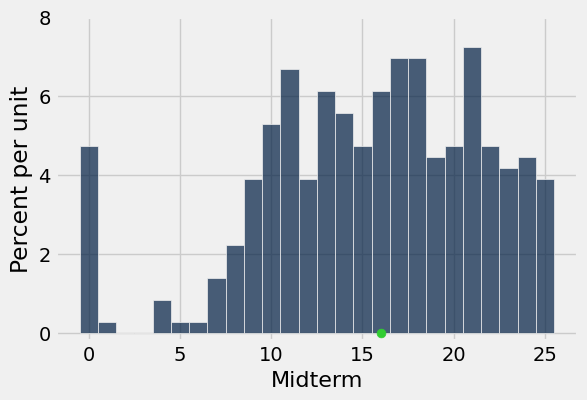

In [18]:
scores_and_sections.hist('Midterm', bins = np.arange(-0.5,25.6, 1))

### plot the_median using following code
parameter_green = '#32CD32'
plots.ylim(-0.002, .08)
plots.scatter(the_median, 0, color=parameter_green, s=40, zorder=2)

Note: Your histogram should look like this:

<img src="midterm.jpg" width = 350>

What function puts the green dot on the histogram? 

<font color='blue'> ... _plots.scatter puts the green dot on the histograms while plots.ylim puts the green dot on a certain coordinate._</font>

## 2. The Bootstrap Process

We will use bootstrap to estimate the population median. The idea is, we have some delay data in minutes about United Airline. We want to estimate how many minutes delay we will experence if we take United Airline. (This can be interpreted as we are treating the United Airline delay dataset as the population dataset, which is usually not available.)

**q2.1.1** 

load the dataset 'united_summer2015.csv' and call it united

In [19]:
united = Table.read_table(path_data + 'united_summer2015.csv')

**q2.1.2** 

show the first three lines of sf2019 using the show() function

In [22]:
united.show(3)

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3


**q2.1.3** stats()

The stats() function gives us basic descriptive statistics about the table.

In [23]:
### just run this cell
united.stats()

statistic,Date,Flight Number,Destination,Delay
min,6/1/15,3,ANC,-16
max,8/9/15,2117,STL,580
median,,1178,,2
sum,,1.56695e+07,,230299


**q2.1.4** 

Based on the output of the code, above, which of the following would be a good bins for displaying a histogram of the Delay minutes? Place your answer in the cell below. 

1. np.arange(-20, 600, 10)
2. np.arange(-20, 580, 10)
3. np.arange(-10, 580, 10)
4. np.arange(-10, 600, 10)

<font color='blue'>  _1._</font>

**q2.2** Visualization

Use the bins you choose above to create a hitogram to show the "Delay" information in the united table.

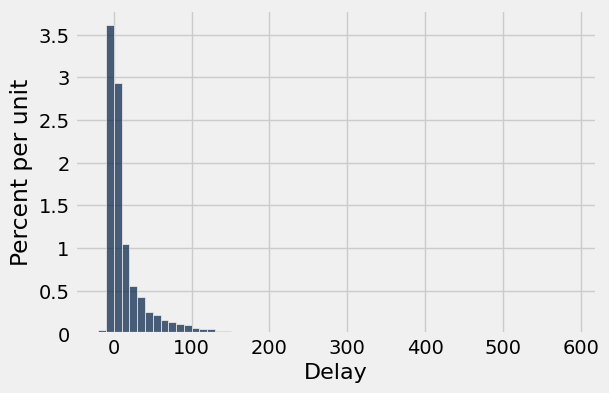

In [27]:
bins = np.arange(-20, 600, 10)         ### use your bin
united.hist('Delay', bins = bins)     ### create histogram

**q2.3.** Data cleasing

Obvriously the right tail of this distribution is very long and we should consider reasonable data cleasing. Supposed you are a domain expert and you think we should use 150 minutes as a cutoff point for this task. 

Use a line of code to remove the rows with greator than 150 minutes in delay. Reassign the new table to  name it united_cleaned.

In [28]:
### write your line of code here
united_cleaned = united.where('Delay', are.below_or_equal_to(150))

In [29]:
### just run this cell to see the stats
united_cleaned.stats()

statistic,Date,Flight Number,Destination,Delay
min,6/1/15,3,ANC,-16
max,8/9/15,2117,STL,150
median,,1178,,2
sum,,1.54054e+07,,177229


**q2.3.3** 

Use the num_row attribute to check the number of rows in the united_cleaned table.

In [30]:
### type your code here
united.num_rows

13825

We want to visualize the cleaned data

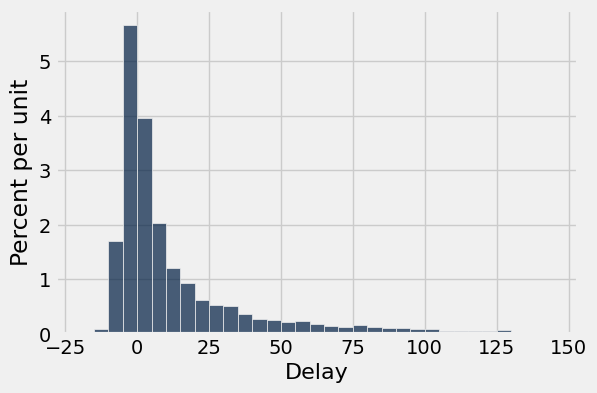

In [35]:
### NOTE THAT we defined a new bins variable here.
### just run the code
new_bins = np.arange(-20, 150, 5)
united_cleaned.select('Delay').hist(bins=new_bins)

**q2.4.** The paramter: median

Calculate the median of the minutes of delay using one line of code and call it pop_median.

In [36]:
pop_median = percentile(50, united.column('Delay'))
pop_median

2

**q2.4.** Random sampling

- draw a sample of 500 delays at random without replacement from the cleaned table
- visualize the data to see how different it is from the population

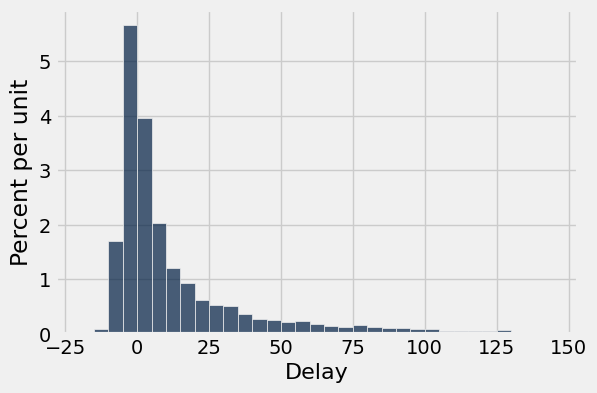

In [37]:
our_sample = united.sample(500, with_replacement = False)    ### 500 random samples
united_cleaned.select('Delay').hist(bins=new_bins)         ### histogram using the new bin

**q2.5.** Estimate the parameter

- find the median delay of the sampled employees serve as our estimate of the parameter
- Use a one-line code to calculate the estimated median of our sample.
- the result should not be too far away from the pop_median

In [39]:
sample_median = percentile(50, our_sample.column('Delay'))
sample_median

3

**q2.6.** The bootstrap: A resampled median

- use a one-line code to resample the our_sample distribution and create a delay histogram.

In [41]:
### resample our_sample and call it resample_1
resample_1 = our_sample.sample()
resample_1

Date,Flight Number,Destination,Delay
7/9/15,300,HNL,4
7/28/15,1670,HNL,8
6/8/15,1742,LAS,78
7/31/15,1185,EWR,-5
6/29/15,1950,CLE,85
6/8/15,1401,SAN,-2
7/5/15,1438,EWR,-3
6/7/15,1185,EWR,36
6/16/15,1250,IAH,-1
6/4/15,1964,SEA,0


- just to check how different this resampling is from the original sample (our_sample)
- create a delay histogram of resample_1 using new_bins

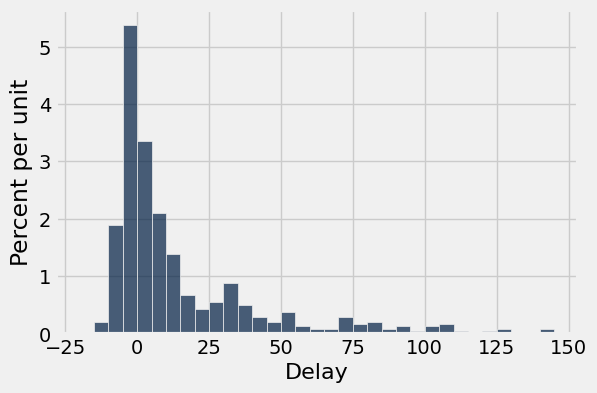

In [42]:
### histogram of resample_1 on delay
resample_1.select('Delay').hist(bins=new_bins) 

**q2.7.** 

calculate the estiamte of the population median and call it resample_median_1

In [43]:
resample_median_1 = percentile(50, resample_1.column('Delay'))    ### resample_median_1
resample_median_1                                                 ### evaluate resample_median_1

4

**q2.8** resample the sample many tims to create an empirical distution of the estimates:

- define a function, call it one_bootstrap_median, to retunr one bootstrapped median of delays based on the original random sample "our_sample". 

In [47]:
def one_bootstrap_median():                                        ### function header
    resample_tbl = our_sample.sample()                             ### sample our_sample to a new table, call it resample_tbl
    bootstrapped_median = percentile(50, resample_tbl.column('Delay')) ### calculate the median, call it bootstrapped_median
    return bootstrapped_median                                         ### return the obtained median

In [48]:
### calling this function multiple times (Control+Enter) should help your understanding about resampling
one_bootstrap_median()

4

**q2.9.** bootstrap empirical distribution of the sample median

1. we are asking for 5000 repetitions. Create a variable for this and call it num_repetitions.
2. create an empty array called bstrap_medians.
3. design a for loop to call the one_bootstrap_median function 5000 times and save the medians to the array.

In [49]:
num_repetitions = 5000                 ### define num_repetitions
bstrap_medians = make_array()          ### create the empty array called bstrap_medians
for i in np.arange(num_repetitions):   ### a for loop to run num_repetitions times
    bstrap_medians = np.append (bstrap_medians, one_bootstrap_median())     ### append the medians to the array

In [51]:
### use the stats() function for basic information
### run the code and observe the table
### we can use the min/max for our bins
resampled_medians = Table().with_column('Bootstrap Sample Median', bstrap_medians)
resampled_medians.stats()

statistic,Bootstrap Sample Median
min,0
max,6
median,3
sum,14589


**q2.10.** turn the median array to a table so that we can visualize the distribution

- create and call the table resampled_medians
- create a histogram with bins (0.5, 5.1, 1) based on the stats above

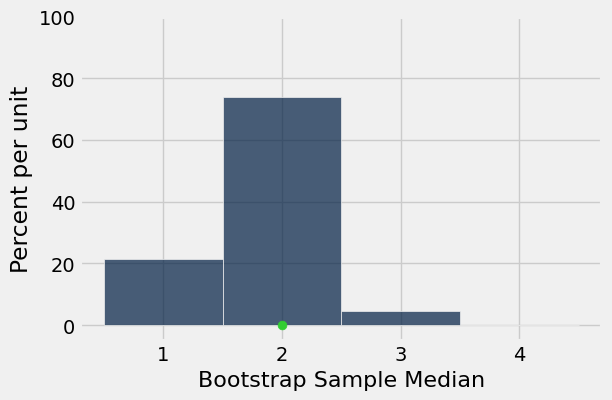

In [102]:
resampled_medians.hist(bins = np.arange(0.5, 5.1, 1))

# plotting the pop_median; you can ignore this code
parameter_green = '#32CD32'
plots.ylim(-0.05, 1)
plots.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2);

**q2.11.** do the estimates capture the parameter?

- calculating the “middle 95%” interval of resampled medians: 

In [55]:
left = percentile(2.5, bstrap_medians)         ### the left 2.5%
right = percentile(97.5, bstrap_medians)       ### the right 97.5%
make_array(left, right)

array([ 1.,  4.])

**q2.12** 

is the population median between the two numbers (left and right)?

_<font color='blue'>Yes</font>_

**q2.13.** plotting the histogram

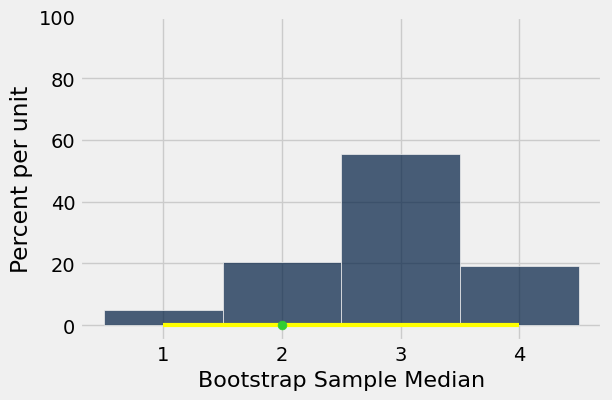

In [58]:
### run the code
resampled_medians.hist(bins = np.arange(0.5, 5.1, 1))

# plotting parameters; you can ignore this code
plots.ylim(-0.05, 1)
plots.plot([left, right], [0, 0], color='yellow', lw=3, zorder=1)
plots.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2);

Your histogram should look like this:

<img src='medians_intervals.jpg' width=450>

- The “middle 95%” interval of estimates captured the parameter in our example. 

<p>&nbsp;</p>

`Good Job! You are done with this assignment!`

## Submission Instructions

Follow these steps to submit your work:

1. Save your notebook file:
   - Click on File -> Save Notebook, or simply click on the Save icon.
2. Restart Kernel and Run All Cells:
   - In the menu, go to Kernel → Restart Kernel and Run All Cells.
3. Verify your work:
   - Scroll through the notebook to ensure everything runs smoothly without unexpected error messages. 
   - In case of interruptions caused by execution errors, use "Run ==> Selected Cell and All Below" to continue execution. 
4. Save the notebook again to confirm all changes.
5. Create a duplicate notebook for submission:
   - In the Jupyter Notebook dashboard/homepage, create a duplicate of this notebook
   - Rename the duplicate from *assignment.ipynb_copy* to *assignment_FIRSTNAME_LASTNAME.ipynb* (e.g., *a01_TSANGYAO_CHEN.ipynb*) for submission.
   - Keep your original notebook file as a backup.
6. Upload your renamed notebook to Canvas.